In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torchmetrics import Accuracy, F1Score, AUROC, Precision, Recall
from HistoLib import pytorch_mil, pytorch_dataset, pytorch_model, utils


In [2]:
utils.dataset_description()


Total images 691
Total patients 45


,20x,40x,Total
aca_bd,57,46,103
aca_md,44,46,90
aca_pd,45,42,87
nor,85,66,151
scc_bd,50,49,99
scc_md,30,36,66
scc_pd,48,47,95
Total,359,332,691


## Get images

In [3]:
resolution = '20x'      # One of ['20x', '40x']
train_loader, val_loader, test_loader, class_names = pytorch_mil.get_mil_dataloaders(
    resolution=resolution,
    batch_size=3,
    image_scale=0.25, # Consistent with baseline
    reproducible=True # Use the splits from the original paper.
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")
def show_batch(loader, title="Batch", num_images=12):
    import random
    import torch
    
    target_num_classes = len(class_names)
    images_per_class = (num_images // target_num_classes) + 1
    class_images = {i: [] for i in range(target_num_classes)}
    
    for images, labels in loader:
        for i in range(len(images)):
            lbl = labels[i].item()
            img = images[i][0]  # Take first patch of the bag
            if len(class_images[lbl]) < images_per_class:
                class_images[lbl].append(img)
        
        # Check if we've met the quota for all classes
        if all(len(v) >= images_per_class for v in class_images.values()):
            break
            
    all_images = []
    all_labels = []
    
    # Extract exactly num_images, balanced across classes
    for lbl, imgs in class_images.items():
        for img in imgs:
            if len(all_images) < num_images:
                all_images.append(img)
                all_labels.append(torch.tensor(lbl))
                
    # Shuffle them to mix classes in the plot
    indices = list(range(len(all_images)))
    random.shuffle(indices)
    
    plt.figure(figsize=(15, 10))
    for i in range(min(num_images, len(all_images))):
        idx = indices[i]
        plt.subplot(3, 4, i + 1)
        img = all_images[idx].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"Class: {class_names[all_labels[idx].item()]}")
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

Number of training batches: 88
Number of validation batches: 16
Number of test batches: 16


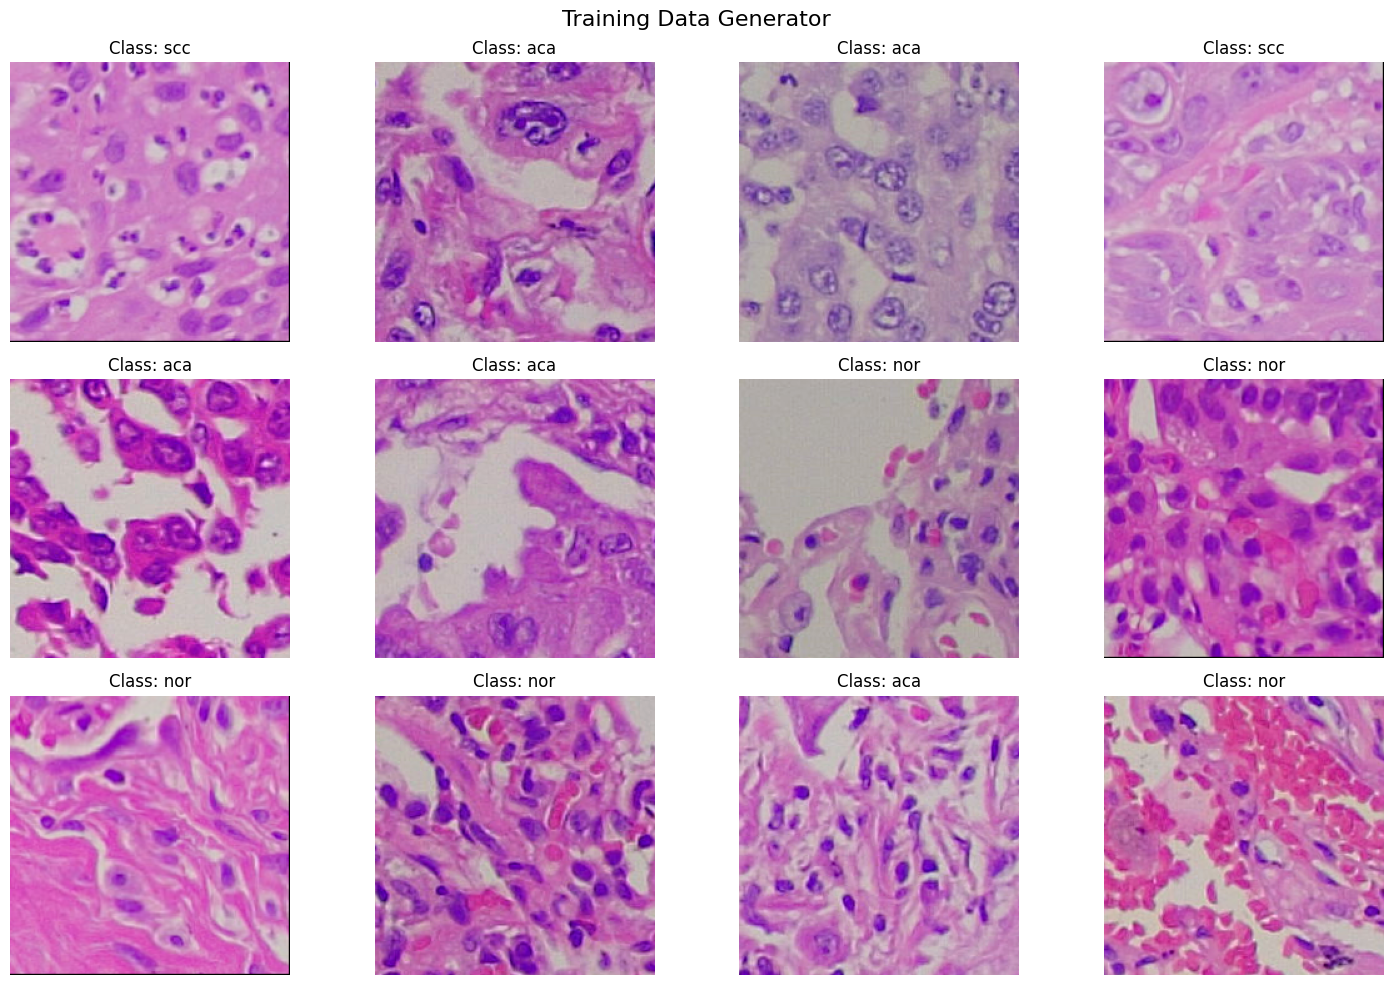

In [4]:
show_batch(train_loader, "Training Data Generator")


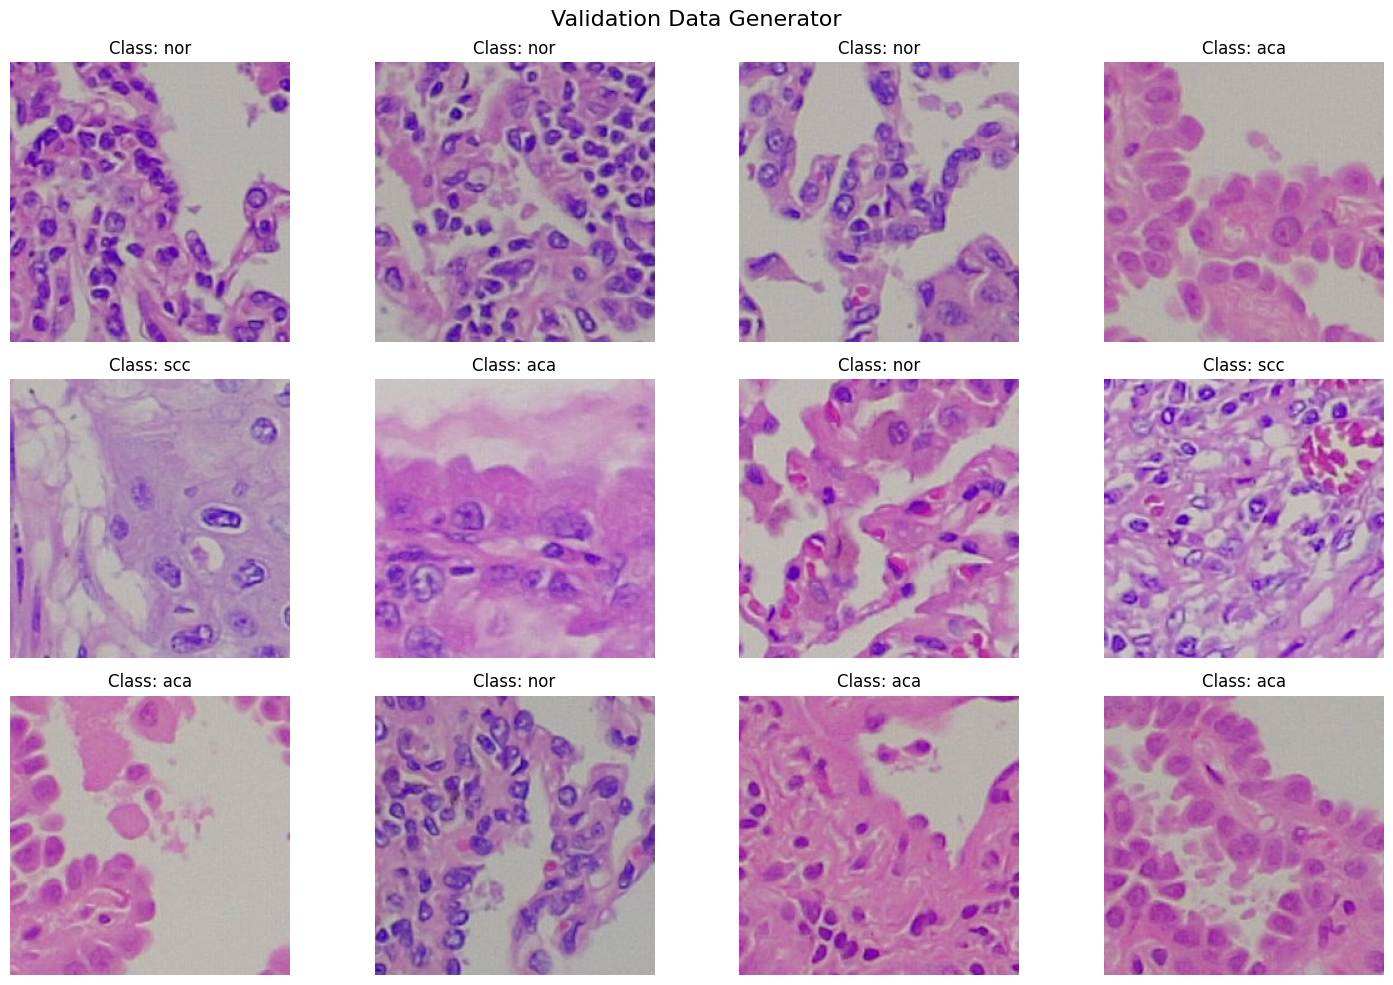

In [5]:
show_batch(val_loader, "Validation Data Generator")


## Train Model

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
num_classes = len(class_names)
model = pytorch_mil.MIL_ResNet50(num_classes=num_classes).to(device)


Using device: cuda


In [7]:
# Compute class weights
train_labels = train_loader.dataset.labels
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
weights = total_samples / (num_classes * class_counts)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1)
metrics_collection = {
    'acc': Accuracy(task="multiclass", num_classes=num_classes).to(device),
    'f1': F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'auc': AUROC(task="multiclass", num_classes=num_classes).to(device),
    'precision': Precision(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'recall': Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
}
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_auc': [], 'val_auc': []}
epochs = 30
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        pbar.set_postfix({'loss': loss.item()})
        
    train_loss = running_loss / len(train_loader)
    train_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    
    model.eval()
    val_running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            for m in metrics_collection.values(): m(outputs, labels)
            
    val_loss = val_running_loss / len(val_loader)
    val_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['train_auc'].append(train_metrics['auc'])
    history['val_auc'].append(val_metrics['auc'])
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Acc: {train_metrics['acc']:.4f} - Val Loss: {val_loss:.4f}, Acc: {val_metrics['acc']:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'mil_baseline_best.pth')


Epoch 1/30 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


Epoch 1/30 - Train Loss: 0.9023, Acc: 0.5361 - Val Loss: 1.2692, Acc: 0.5000


Epoch 2/30 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/30 - Train Loss: 0.6185, Acc: 0.7110 - Val Loss: 0.9539, Acc: 0.6458


...

Epoch 28/30 - Train Loss: 0.1652, Acc: 0.9240 - Val Loss: 0.7734, Acc: 0.7083


Epoch 29/30 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 29/30 - Train Loss: 0.1465, Acc: 0.9392 - Val Loss: 0.8732, Acc: 0.7083


Epoch 30/30 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 30/30 - Train Loss: 0.1638, Acc: 0.9278 - Val Loss: 0.9084, Acc: 0.7083


## Evaluate using test data

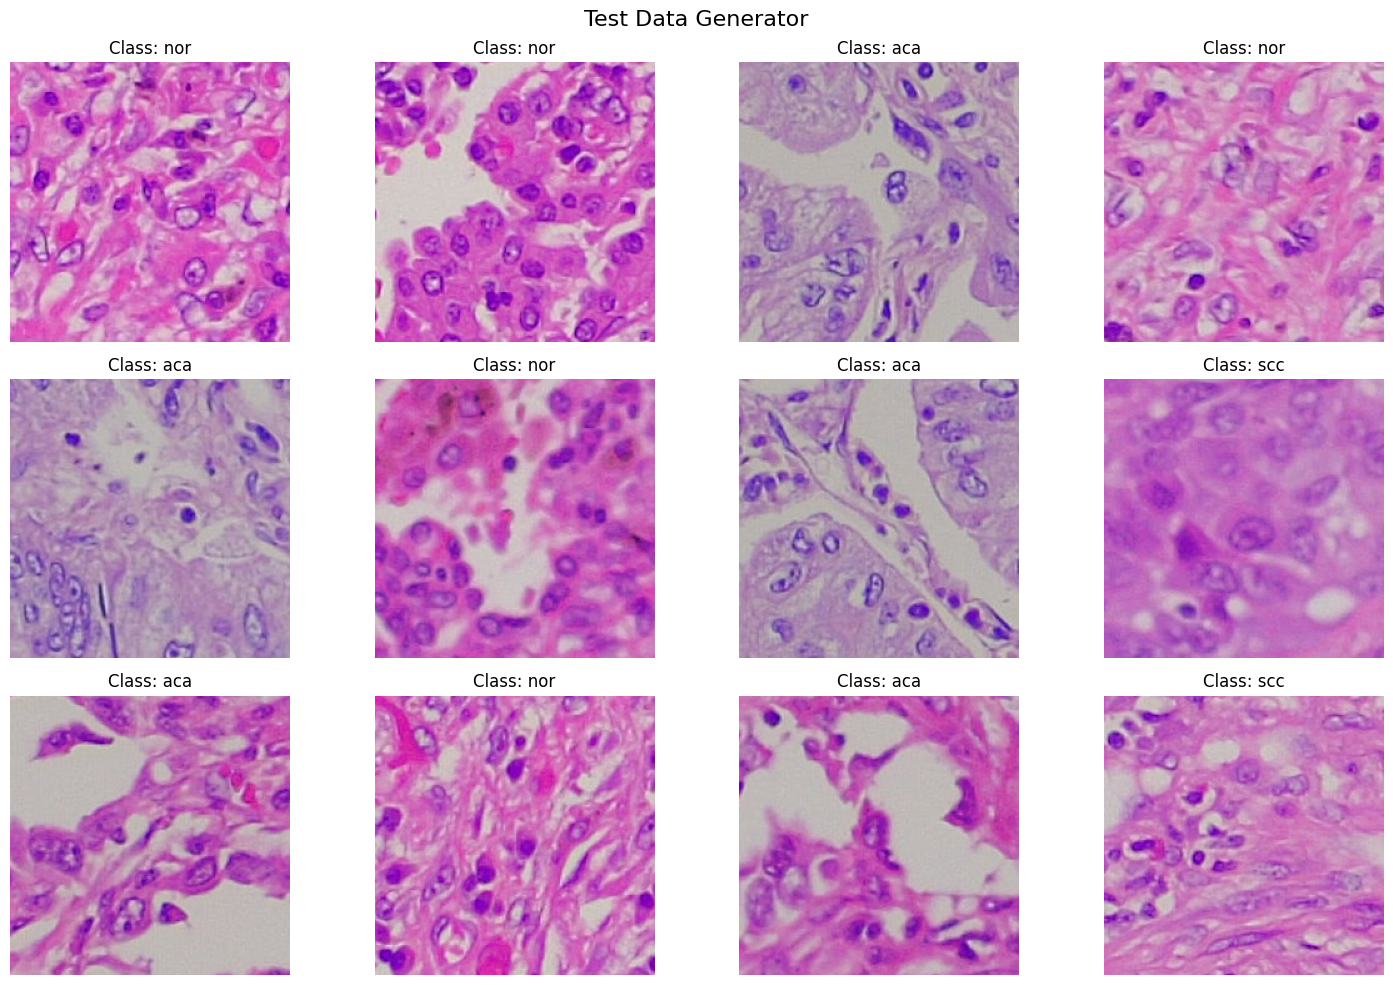

In [8]:
show_batch(test_loader, "Test Data Generator")


/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)
/home/skattoju/code/LungHist700/.venv/lib64/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


Test Loss: 0.8207
Test Accuracy: 0.7083
Test F1 Score: 0.7009
Test AUC: 0.9131
Test Precision (Macro): 0.7713
Test Recall (Macro): 0.7033


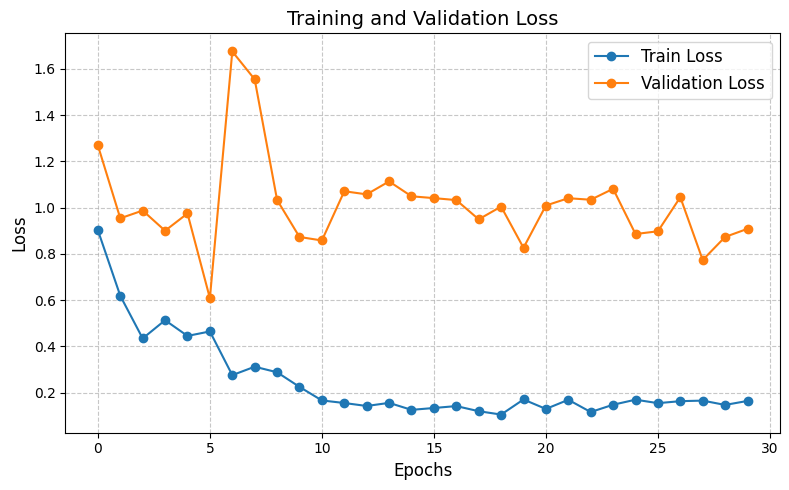

Saved mil_baseline_loss.png


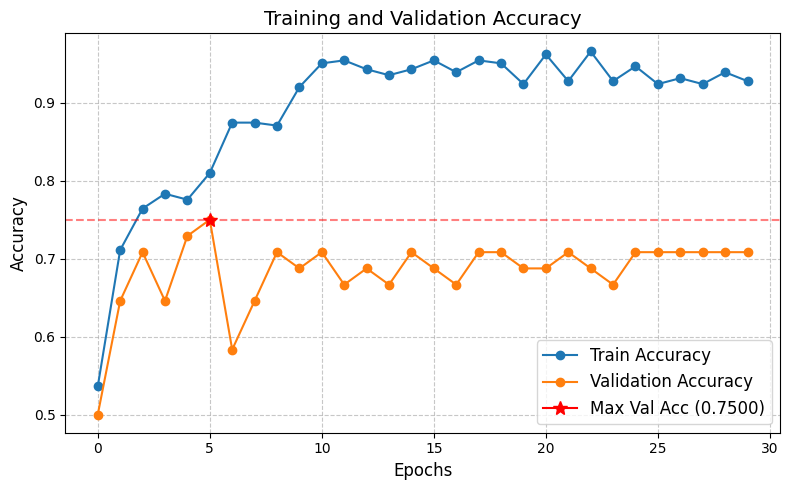

Saved mil_baseline_accuracy.png


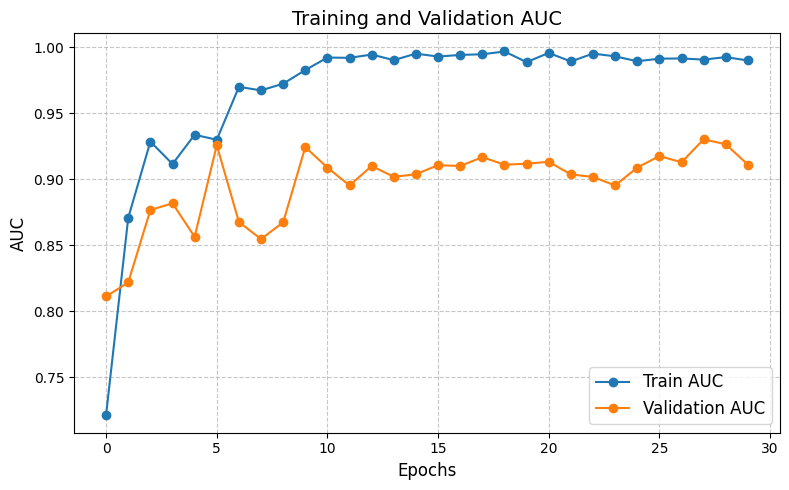

Saved mil_baseline_auc.png


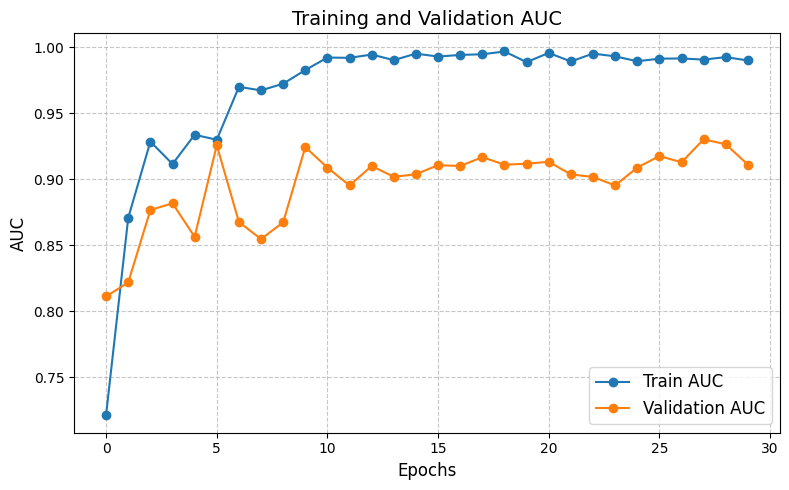

Saved mil_baseline_auc.png


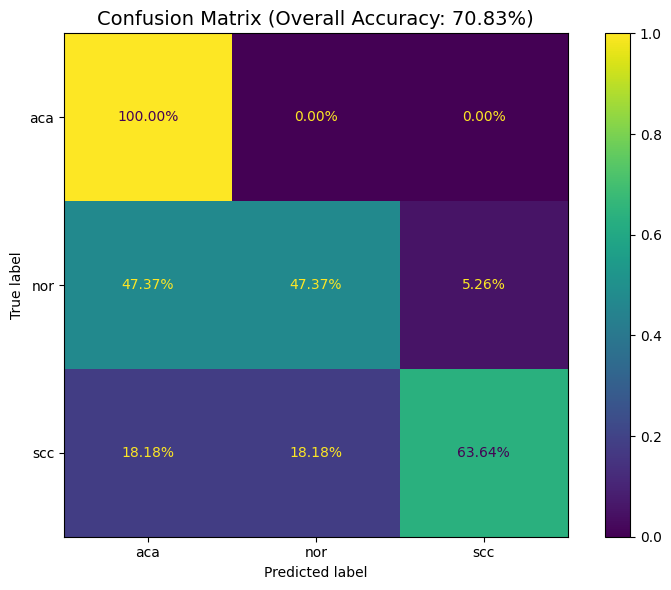

Saved mil_baseline_confusion_matrix.png


In [11]:
model.load_state_dict(torch.load("mil_baseline_best.pth"))
model.eval()
test_loss = 0.0
for m in metrics_collection.values(): m.reset()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_loss /= len(test_loader)
test_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['acc']:.4f}")
print(f"Test F1 Score: {test_metrics['f1']:.4f}")
print(f"Test AUC: {test_metrics['auc']:.4f}")
print(f"Test Precision (Macro): {test_metrics['precision']:.4f}")
print(f"Test Recall (Macro): {test_metrics['recall']:.4f}")
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# --- Plot 1: Training Loss ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_loss'], label='Train Loss', marker='o')
ax.plot(history['val_loss'], label='Validation Loss', marker='o')
ax.set_title('Training and Validation Loss', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_loss.png")

# --- Plot 2: Training Accuracy ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax.plot(history['val_acc'], label='Validation Accuracy', marker='o')
max_val_acc = max(history['val_acc'])
max_epoch = history['val_acc'].index(max_val_acc)
ax.axhline(y=max_val_acc, color='r', linestyle='--', alpha=0.5)
ax.plot(max_epoch, max_val_acc, marker='*', color='r', markersize=10, label=f'Max Val Acc ({max_val_acc:.4f})')
ax.set_title('Training and Validation Accuracy', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_accuracy.png")



# --- Plot 3: Training AUC ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_auc'], label='Train AUC', marker='o')
ax.plot(history['val_auc'], label='Validation AUC', marker='o')
ax.set_title('Training and Validation AUC', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_auc.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_auc.png")


# --- Plot 4: Training AUC ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_auc'], label='Train AUC', marker='o')
ax.plot(history['val_auc'], label='Validation AUC', marker='o')
ax.set_title('Training and Validation AUC', fontsize=14)
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('mil_baseline_auc.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_auc.png")


# --- Plot 5: Confusion Matrix (normalized, showing per-class accuracy) ---
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=class_names,
    normalize='true',
    values_format='.2%',
    ax=ax
)
ax.set_title(f"Confusion Matrix (Overall Accuracy: {test_metrics['acc']:.2%})", fontsize=14)
plt.tight_layout()
plt.savefig('mil_baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved mil_baseline_confusion_matrix.png")


Generating MIL Attention Visualization samples...
Saved mil_attention_viz.png


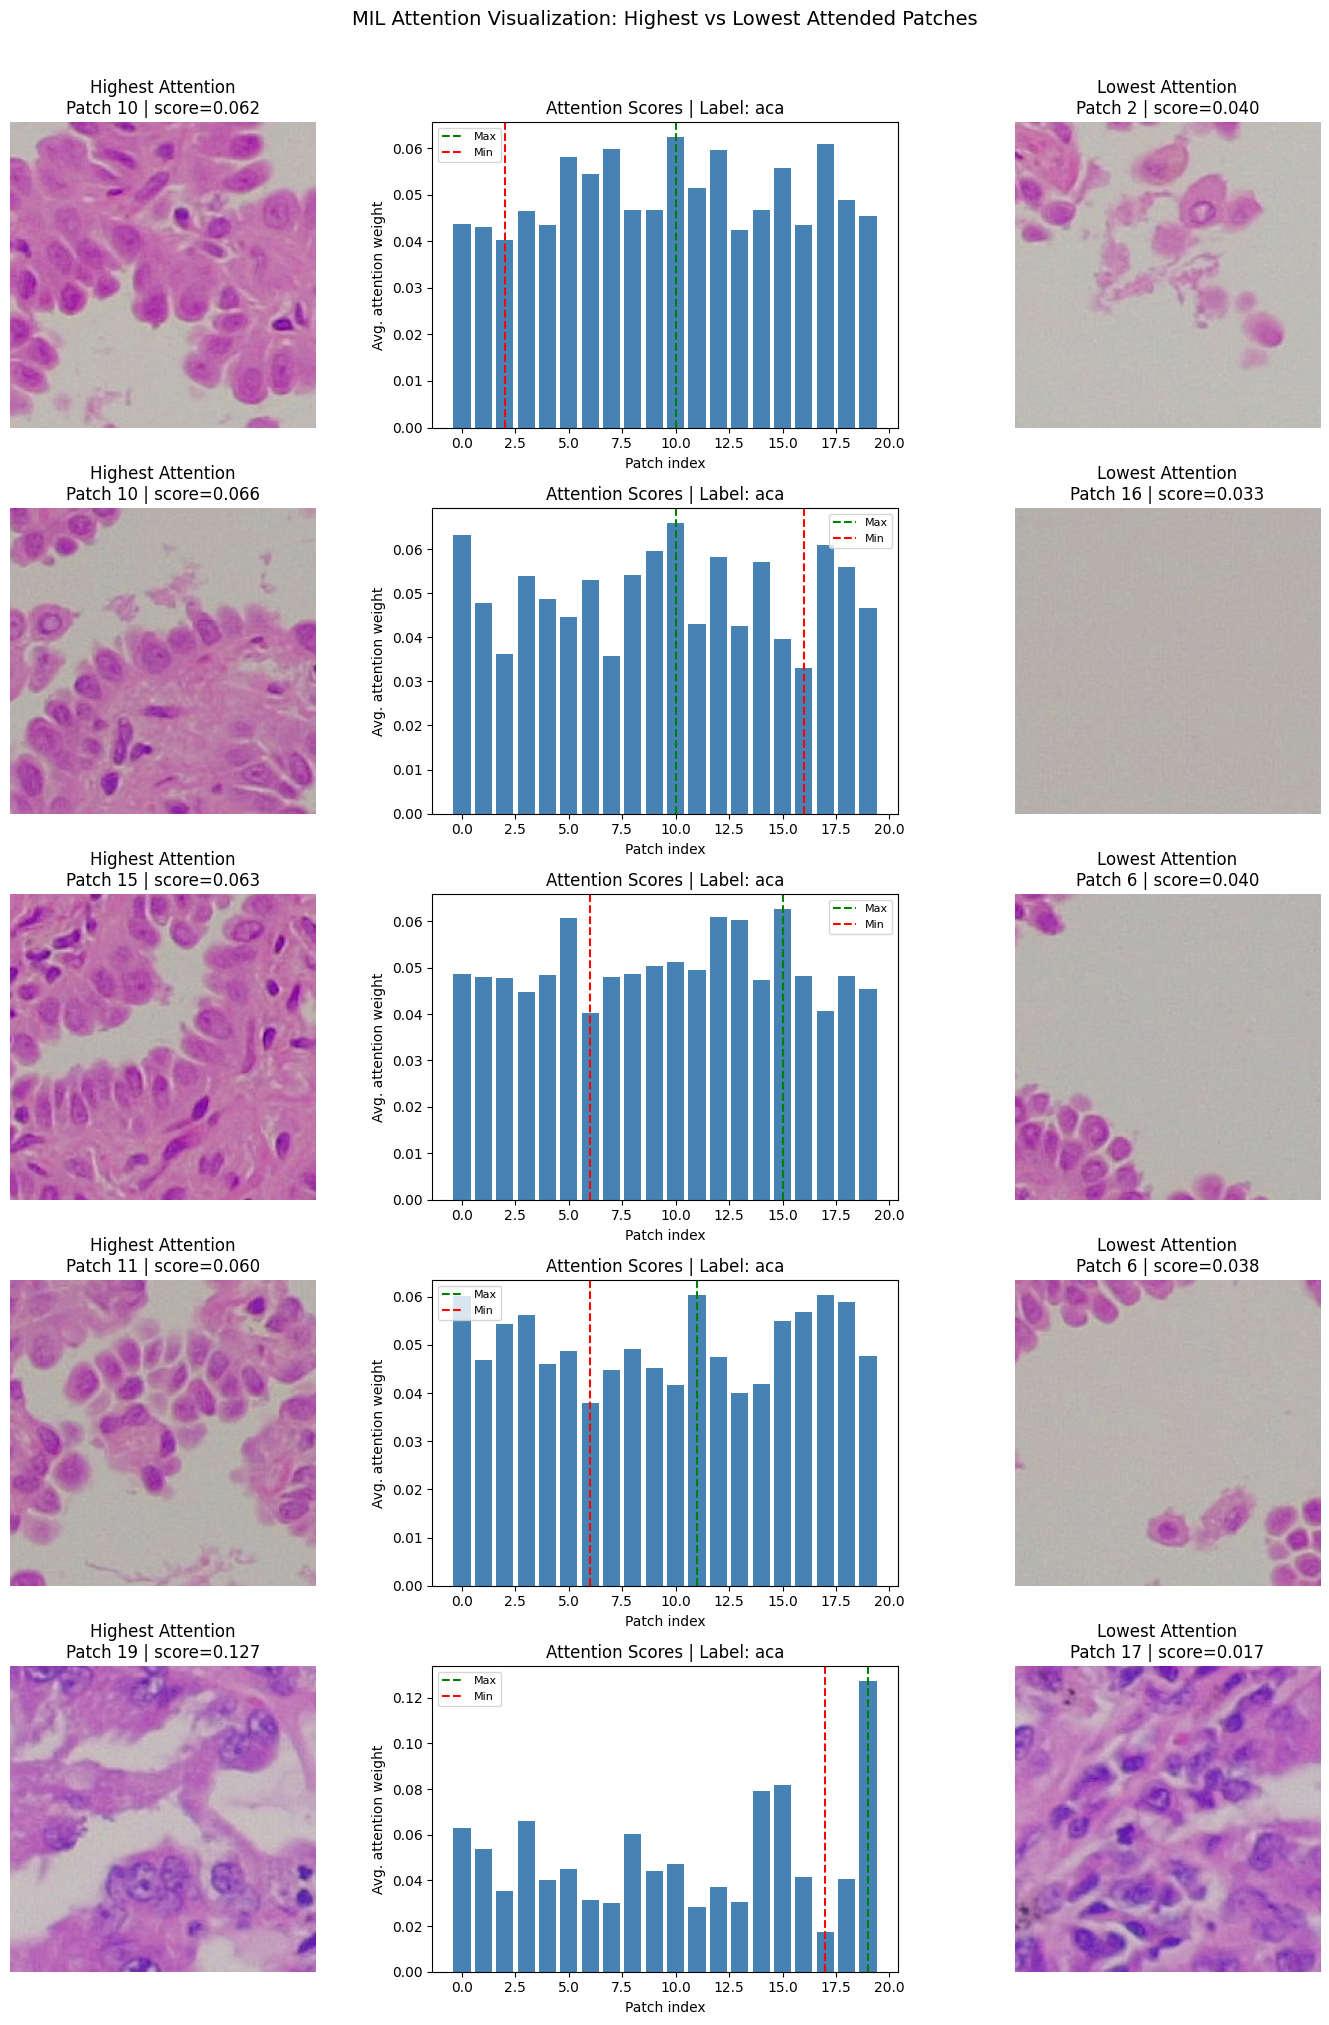

In [13]:
print("Generating MIL Attention Visualization samples...")
model.eval()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

num_samples = 5
images_shown = 0
fig, axs = plt.subplots(num_samples, 3, figsize=(15, num_samples * 4))

for bags, labels in val_loader:
    bags = bags.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        B, N, C, H, W = bags.shape
        bags_flat = bags.view(B * N, C, H, W)
        features = model.backbone(bags_flat).view(B, N, model.embed_dim)
        _, attn_weights = model.attention(features, features, features, average_attn_weights=True)
        patch_importance = attn_weights.mean(dim=1)  # [B, N]

    for b in range(B):
        if images_shown >= num_samples:
            break
        label_idx = labels[b].item()
        importance = patch_importance[b].cpu().numpy()
        top_idx = int(importance.argmax())
        bot_idx = int(importance.argmin())

        def denorm(t):
            img = t.cpu().numpy().transpose(1, 2, 0)
            return np.clip(std * img + mean, 0, 1)

        row = images_shown
        axs[row, 0].imshow(denorm(bags[b, top_idx]))
        axs[row, 0].set_title(f"Highest Attention\nPatch {top_idx} | score={importance[top_idx]:.3f}")
        axs[row, 0].axis("off")

        axs[row, 1].bar(range(N), importance, color="steelblue")
        axs[row, 1].axvline(top_idx, color="green", linestyle="--", label="Max")
        axs[row, 1].axvline(bot_idx, color="red",   linestyle="--", label="Min")
        axs[row, 1].set_title(f"Attention Scores | Label: {class_names[label_idx]}")
        axs[row, 1].set_xlabel("Patch index")
        axs[row, 1].set_ylabel("Avg. attention weight")
        axs[row, 1].legend(fontsize=8)

        axs[row, 2].imshow(denorm(bags[b, bot_idx]))
        axs[row, 2].set_title(f"Lowest Attention\nPatch {bot_idx} | score={importance[bot_idx]:.3f}")
        axs[row, 2].axis("off")

        images_shown += 1

    if images_shown >= num_samples:
        break

plt.suptitle("MIL Attention Visualization: Highest vs Lowest Attended Patches", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("mil_attention_viz.png", dpi=150, bbox_inches="tight")
print("Saved mil_attention_viz.png")
# import matplotlib.image as mpimg
# img = mpimg.imread("mil_attention_viz.png")
# plt.figure(figsize=(18, num_samples * 4))
# plt.imshow(img)
plt.axis("off")
plt.show()